#🧠 Thyroid Disease Detection using Machine Learning

##📌 Project Overview
This project focuses on predicting thyroid cancer risk using machine learning techniques. It involves data preprocessing, exploratory data analysis (EDA), feature engineering, and classification models to detect whether a patient has Benign or Malignant thyroid conditions.

The dataset contains 212,000+ patient records, making it a large-scale, real-world healthcare dataset.[link text](https://)

<img src = "https://i.postimg.cc/BvrNCs9L/Chat-GPT-Image-Apr-10-2026-08-50-50-PM.png">

## 📚 Importing Libraries

This project uses the following Python libraries:

- NumPy → Numerical computations  
- Pandas → Data manipulation and analysis  
- Matplotlib & Seaborn → Data visualization  

These libraries help in handling large datasets and building machine learning models efficiently.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 📥 Loading Dataset

The dataset is loaded from a CSV file containing thyroid cancer risk data.

- Total Records: ~212,000+
- Total Features: 17  

The dataset includes patient medical history, lab results, and diagnosis.

In [ ]:
df = pd.read_csv("/content/thyroid_cancer_risk_data.csv")

## 🔍 Dataset Overview

The dataset contains:

- Numerical features: Age, TSH, T3, T4, Nodule Size  
- Categorical features: Gender, Smoking, Diabetes, etc.  
- Target Variable: Diagnosis (Benign / Malignant)  

Understanding data types helps in preprocessing and model building.

In [ ]:
df.shape

(212691, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212691 entries, 0 to 212690
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Patient_ID           212691 non-null  int64  
 1   Age                  212691 non-null  int64  
 2   Gender               212691 non-null  object 
 3   Country              212691 non-null  object 
 4   Ethnicity            212691 non-null  object 
 5   Family_History       212691 non-null  object 
 6   Radiation_Exposure   212691 non-null  object 
 7   Iodine_Deficiency    212691 non-null  object 
 8   Smoking              212691 non-null  object 
 9   Obesity              212691 non-null  object 
 10  Diabetes             212691 non-null  object 
 11  TSH_Level            212691 non-null  float64
 12  T3_Level             212691 non-null  float64
 13  T4_Level             212691 non-null  float64
 14  Nodule_Size          212691 non-null  float64
 15  Thyroid_Cancer_Ri

In [ ]:
df.columns

Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size',
       'Thyroid_Cancer_Risk', 'Diagnosis'],
      dtype='object')

In [ ]:
df.head()

,Patient_ID,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
0,1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
1,2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
2,3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
3,4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
4,5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign


## 🔢 Setting Patient ID as Index

The 'Patient_ID' column is set as the index to uniquely identify each patient.

This improves data organization and retrieval.

In [ ]:
df = df.set_index("Patient_ID")

In [ ]:
df

,Age,Gender,Country,Ethnicity,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
Patient_ID,,,,,,,,,,,,,,,,
1,66,Male,Russia,Caucasian,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
2,29,Male,Germany,Hispanic,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
3,86,Male,Nigeria,Caucasian,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
4,75,Female,India,Asian,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
5,35,Female,Germany,African,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212687,58,Female,India,Asian,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212688,89,Male,Japan,Middle Eastern,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212689,72,Female,Nigeria,Hispanic,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign


## 📊 Statistical Summary

Key observations:

- Average Age ≈ 52 years  
- TSH levels range from 0.1 to 10  
- Nodule size varies between 0 and 5  

This helps understand the distribution of medical features.

In [ ]:
df.describe()

,Age,TSH_Level,T3_Level,T4_Level,Nodule_Size
count,212691.000000,212691.000000,212691.000000,212691.000000,212691.000000
mean,51.918497,5.045102,2.001727,8.246204,2.503403
std,21.632815,2.860264,0.866248,2.164188,1.444631
min,15.000000,0.100000,0.500000,4.500000,0.000000
25%,33.000000,2.570000,1.250000,6.370000,1.250000
50%,52.000000,5.040000,2.000000,8.240000,2.510000
75%,71.000000,7.520000,2.750000,10.120000,3.760000
max,89.000000,10.000000,3.500000,12.000000,5.000000


## 🔁 Duplicate Check

The dataset contains no duplicate records.

This ensures data quality and reliability.

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Age'].unique()

array([66, 29, 86, 75, 35, 89, 38, 17, 36, 67, 16, 44, 52, 78, 74, 47, 72,
       63, 73, 56, 76, 61, 65, 69, 21, 87, 53, 32, 18, 28, 23, 85, 58, 22,
       49, 50, 64, 20, 68, 77, 48, 88, 62, 54, 40, 55, 43, 59, 79, 15, 25,
       19, 42, 26, 37, 51, 41, 57, 27, 46, 80, 71, 84, 70, 33, 82, 31, 83,
       30, 34, 81, 45, 39, 60, 24])

## 📊 Diabetes vs Diagnosis

A countplot is used to analyze the relationship between diabetes and thyroid cancer diagnosis.

Insight:
Patients with diabetes show variation in cancer diagnosis distribution.

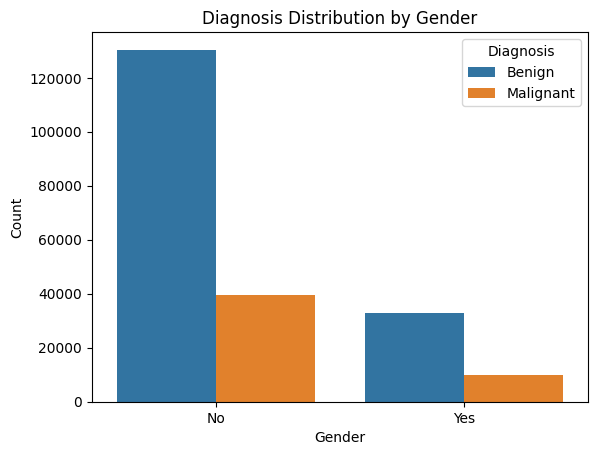

In [ ]:
sns.countplot(x='Diabetes', hue='Diagnosis', data=df)
plt.title('Diagnosis Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 📅 Age-wise Thyroid Analysis

The distribution of diagnosis across different age groups is analyzed.

Insight:
Certain age groups show higher occurrences of thyroid conditions.

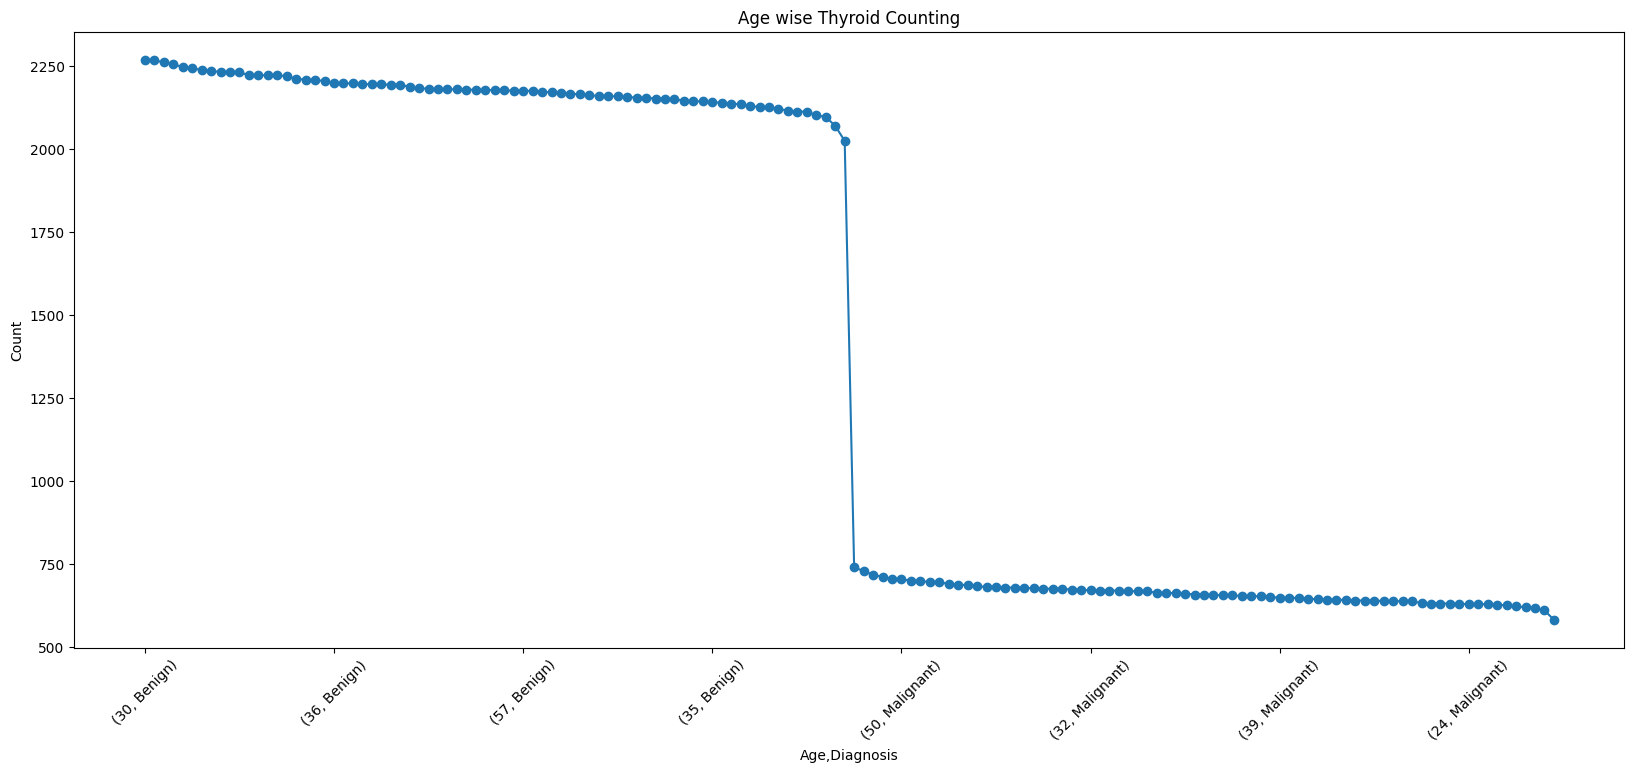

In [ ]:
df.groupby("Age")["Diagnosis"].value_counts().sort_values(ascending=False).plot(kind="line",marker="o" ,figsize=(20, 8))
plt.title("Age wise Thyroid Counting")
plt.ylabel("Count")
plt.xlabel("Age,Diagnosis")
plt.xticks(rotation=45)
plt.show()

## 🚬 Smoking vs Diagnosis

The impact of smoking on thyroid cancer is analyzed.

Insight:
Smoking shows noticeable influence on diagnosis categories.

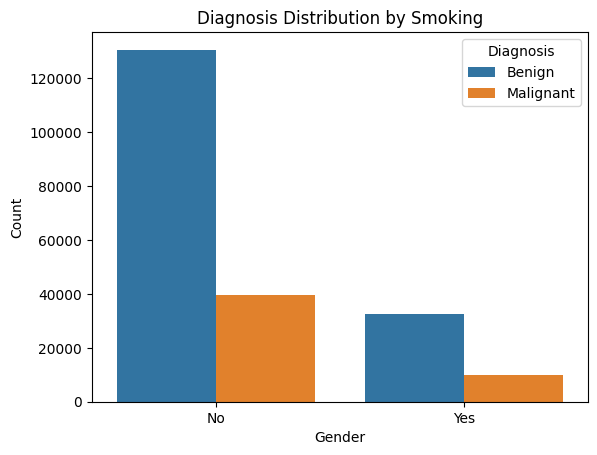

In [ ]:
sns.countplot(x='Smoking', hue='Diagnosis', data=df)
plt.title('Diagnosis Distribution by Smoking')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 🌍 Country Distribution

Histogram shows distribution of patients across countries.

Insight:
Dataset contains diverse global data.

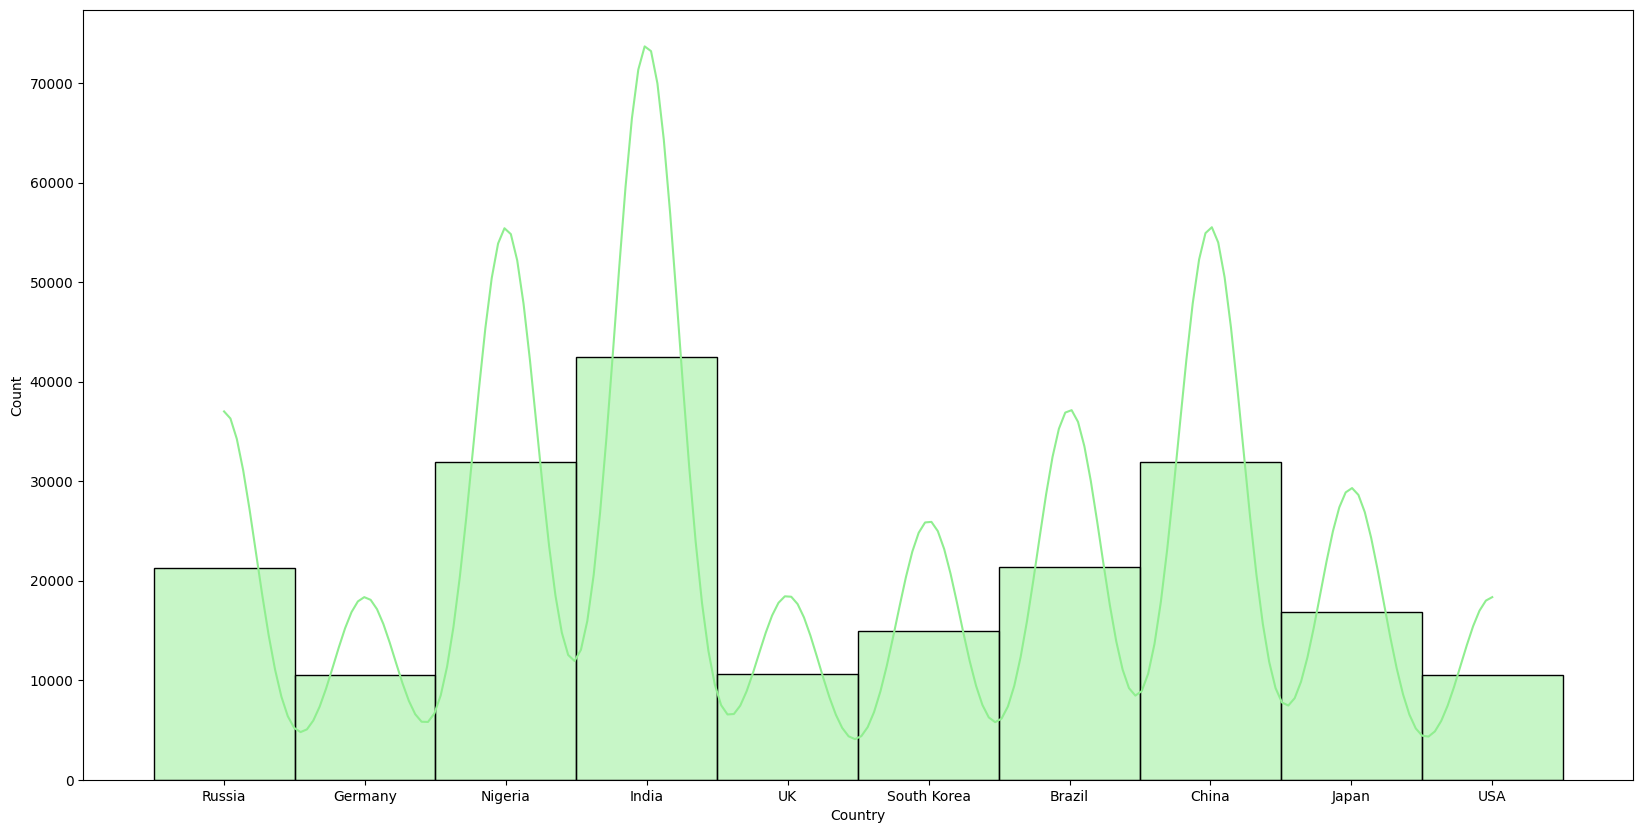

In [ ]:
plt.figure(figsize=(20,10))
sns.histplot(df['Country'],bins=100,kde=True,color="lightgreen")
plt.show()

## 👤 Gender-based Analysis

Comparison of diagnosis across genders.

Insight:
Female patients appear more frequently in the dataset and show higher diagnosis counts.

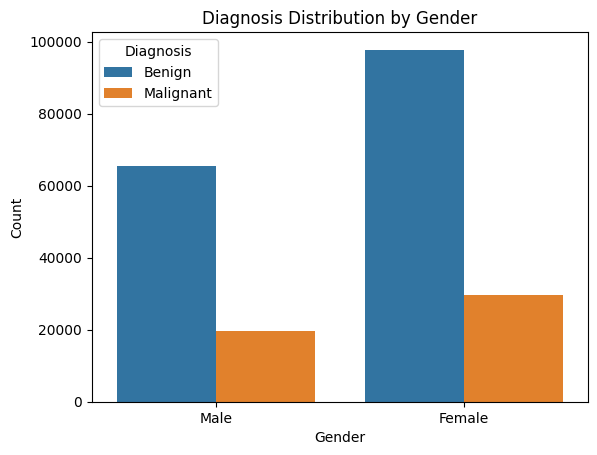

In [ ]:
sns.countplot(x='Gender', hue='Diagnosis', data=df)
plt.title('Diagnosis Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

## 🧪 TSH Level Distribution

Histogram of TSH levels:

- Shows spread of hormone levels  
- Helps identify abnormal ranges  

Important for medical prediction models.

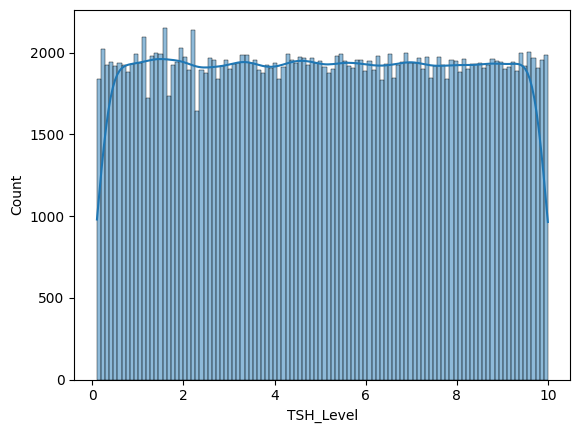

In [ ]:
sns.histplot(df['TSH_Level'],bins=110,kde=True)
plt.show()

## 🧹 Data Cleaning

Columns like Country and Ethnicity are removed as they are not directly relevant for prediction.

This reduces noise and improves model performance.

In [ ]:
df = df.drop(columns=['Country', 'Ethnicity'])


In [ ]:
#df['Diagnosis'] = df['Diagnosis'].replace({'Benign': 0, 'Malignant': 1}) it will without replace

In [ ]:
df

,Age,Gender,Family_History,Radiation_Exposure,Iodine_Deficiency,Smoking,Obesity,Diabetes,TSH_Level,T3_Level,T4_Level,Nodule_Size,Thyroid_Cancer_Risk,Diagnosis
Patient_ID,,,,,,,,,,,,,,
1,66,Male,No,Yes,No,No,No,No,9.37,1.67,6.16,1.08,Low,Benign
2,29,Male,No,Yes,No,No,No,No,1.83,1.73,10.54,4.05,Low,Benign
3,86,Male,No,No,No,No,No,No,6.26,2.59,10.57,4.61,Low,Benign
4,75,Female,No,No,No,No,No,No,4.10,2.62,11.04,2.46,Medium,Benign
5,35,Female,Yes,Yes,No,No,No,No,9.10,2.11,10.71,2.11,High,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212687,58,Female,No,No,No,No,Yes,No,2.00,0.64,11.92,1.48,Low,Benign
212688,89,Male,No,No,No,No,Yes,No,9.77,3.25,7.30,4.46,Medium,Benign
212689,72,Female,No,No,No,No,No,Yes,7.72,2.44,8.71,2.36,Medium,Benign


## 🔄 Encoding Categorical Variables

Categorical variables are converted into numerical format using one-hot encoding.

This allows machine learning models to process categorical data effectively.

In [ ]:
features = ['Age', 'Gender', 'Family_History', 'Radiation_Exposure','Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'TSH_Level','T3_Level', 'T4_Level', 'Thyroid_Cancer_Risk']
df_ml = df[features]
df_ml = pd.get_dummies(df_ml,columns=['Gender', 'Family_History', 'Radiation_Exposure',
       'Iodine_Deficiency', 'Smoking', 'Obesity', 'Diabetes', 'Thyroid_Cancer_Risk',
       ])
df_ml.head()


,Age,TSH_Level,T3_Level,T4_Level,Gender_Female,Gender_Male,Family_History_No,Family_History_Yes,Radiation_Exposure_No,Radiation_Exposure_Yes,...,Iodine_Deficiency_Yes,Smoking_No,Smoking_Yes,Obesity_No,Obesity_Yes,Diabetes_No,Diabetes_Yes,Thyroid_Cancer_Risk_High,Thyroid_Cancer_Risk_Low,Thyroid_Cancer_Risk_Medium
Patient_ID,,,,,,,,,,,,,,,,,,,,,
1,66,9.37,1.67,6.16,False,True,True,False,False,True,...,False,True,False,True,False,True,False,False,True,False
2,29,1.83,1.73,10.54,False,True,True,False,False,True,...,False,True,False,True,False,True,False,False,True,False
3,86,6.26,2.59,10.57,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,True,False
4,75,4.10,2.62,11.04,True,False,True,False,True,False,...,False,True,False,True,False,True,False,False,False,True
5,35,9.10,2.11,10.71,True,False,False,True,False,True,...,False,True,False,True,False,True,False,True,False,False


In [ ]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
Index: 212691 entries, 1 to 212691
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Age                         212691 non-null  int64  
 1   TSH_Level                   212691 non-null  float64
 2   T3_Level                    212691 non-null  float64
 3   T4_Level                    212691 non-null  float64
 4   Gender_Female               212691 non-null  bool   
 5   Gender_Male                 212691 non-null  bool   
 6   Family_History_No           212691 non-null  bool   
 7   Family_History_Yes          212691 non-null  bool   
 8   Radiation_Exposure_No       212691 non-null  bool   
 9   Radiation_Exposure_Yes      212691 non-null  bool   
 10  Iodine_Deficiency_No        212691 non-null  bool   
 11  Iodine_Deficiency_Yes       212691 non-null  bool   
 12  Smoking_No                  212691 non-null  bool   
 13  Smoking_Yes        

## 🎯 Defining Features and Target

- X → Independent variables (features)  
- y → Target variable (Diagnosis)  

Goal:
Predict whether a patient is Benign or Malignant.

In [ ]:
x = df_ml
y = df['Diagnosis']


In [ ]:
x

,Age,TSH_Level,T3_Level,T4_Level,Gender_Female,Gender_Male,Family_History_No,Family_History_Yes,Radiation_Exposure_No,Radiation_Exposure_Yes,...,Iodine_Deficiency_Yes,Smoking_No,Smoking_Yes,Obesity_No,Obesity_Yes,Diabetes_No,Diabetes_Yes,Thyroid_Cancer_Risk_High,Thyroid_Cancer_Risk_Low,Thyroid_Cancer_Risk_Medium
Patient_ID,,,,,,,,,,,,,,,,,,,,,
1,66,9.37,1.67,6.16,False,True,True,False,False,True,...,False,True,False,True,False,True,False,False,True,False
2,29,1.83,1.73,10.54,False,True,True,False,False,True,...,False,True,False,True,False,True,False,False,True,False
3,86,6.26,2.59,10.57,False,True,True,False,True,False,...,False,True,False,True,False,True,False,False,True,False
4,75,4.10,2.62,11.04,True,False,True,False,True,False,...,False,True,False,True,False,True,False,False,False,True
5,35,9.10,2.11,10.71,True,False,False,True,False,True,...,False,True,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212687,58,2.00,0.64,11.92,True,False,True,False,True,False,...,False,True,False,False,True,True,False,False,True,False
212688,89,9.77,3.25,7.30,False,True,True,False,True,False,...,False,True,False,False,True,True,False,False,False,True
212689,72,7.72,2.44,8.71,True,False,True,False,True,False,...,False,True,False,True,False,False,True,False,False,True


In [ ]:
y

,Diagnosis
Patient_ID,
1,Benign
2,Benign
3,Benign
4,Benign
5,Benign
...,...
212687,Benign
212688,Benign
212689,Benign


## 🔗 Correlation Analysis

A heatmap is used to understand relationships between features.

Insight:
Most features show weak correlation, indicating complexity in prediction.

In [ ]:
df_ml.corr()

,Age,TSH_Level,T3_Level,T4_Level,Gender_Female,Gender_Male,Family_History_No,Family_History_Yes,Radiation_Exposure_No,Radiation_Exposure_Yes,...,Iodine_Deficiency_Yes,Smoking_No,Smoking_Yes,Obesity_No,Obesity_Yes,Diabetes_No,Diabetes_Yes,Thyroid_Cancer_Risk_High,Thyroid_Cancer_Risk_Low,Thyroid_Cancer_Risk_Medium
Age,1.000000,-0.000925,-0.001013,-0.002373,0.000151,-0.000151,-0.003337,0.003337,-0.004007,0.004007,...,-0.002368,0.000435,-0.000435,-0.002233,0.002233,0.002590,-0.002590,0.002379,-0.003043,0.001418
TSH_Level,-0.000925,1.000000,0.000335,-0.000795,0.000102,-0.000102,-0.005014,0.005014,-0.000210,0.000210,...,-0.000824,0.000869,-0.000869,-0.001318,0.001318,-0.001751,0.001751,0.002676,-0.001721,-0.000201
T3_Level,-0.001013,0.000335,1.000000,-0.004069,0.003066,-0.003066,-0.001324,0.001324,0.003249,-0.003249,...,0.000024,-0.001163,0.001163,0.001064,-0.001064,-0.001787,0.001787,-0.002498,-0.001277,0.003230
T4_Level,-0.002373,-0.000795,-0.004069,1.000000,0.000114,-0.000114,0.000397,-0.000397,0.000294,-0.000294,...,0.001326,0.000098,-0.000098,-0.002272,0.002272,-0.000569,0.000569,0.000920,-0.003364,0.002856
Gender_Female,0.000151,0.000102,0.003066,0.000114,1.000000,-1.000000,-0.002121,0.002121,-0.000649,0.000649,...,0.002840,-0.003239,0.003239,-0.001941,0.001941,-0.000641,0.000641,0.004524,-0.003784,0.000584
Gender_Male,-0.000151,-0.000102,-0.003066,-0.000114,-1.000000,1.000000,0.002121,-0.002121,0.000649,-0.000649,...,-0.002840,0.003239,-0.003239,0.001941,-0.001941,0.000641,-0.000641,-0.004524,0.003784,-0.000584
Family_History_No,-0.003337,-0.005014,-0.001324,0.000397,-0.002121,0.002121,1.000000,-1.000000,-0.000795,0.000795,...,-0.000550,-0.000406,0.000406,0.000915,-0.000915,-0.000422,0.000422,-0.306087,0.130918,0.092536
Family_History_Yes,0.003337,0.005014,0.001324,-0.000397,0.002121,-0.002121,-1.000000,1.000000,0.000795,-0.000795,...,0.000550,0.000406,-0.000406,-0.000915,0.000915,0.000422,-0.000422,0.306087,-0.130918,-0.092536
Radiation_Exposure_No,-0.004007,-0.000210,0.003249,0.000294,-0.000649,0.000649,-0.000795,0.000795,1.000000,-1.000000,...,-0.002381,0.001947,-0.001947,-0.002236,0.002236,0.000158,-0.000158,-0.187845,0.079562,0.057614
Radiation_Exposure_Yes,0.004007,0.000210,-0.003249,-0.000294,0.000649,-0.000649,0.000795,-0.000795,-1.000000,1.000000,...,0.002381,-0.001947,0.001947,0.002236,-0.002236,-0.000158,0.000158,0.187845,-0.079562,-0.057614


<Axes: >

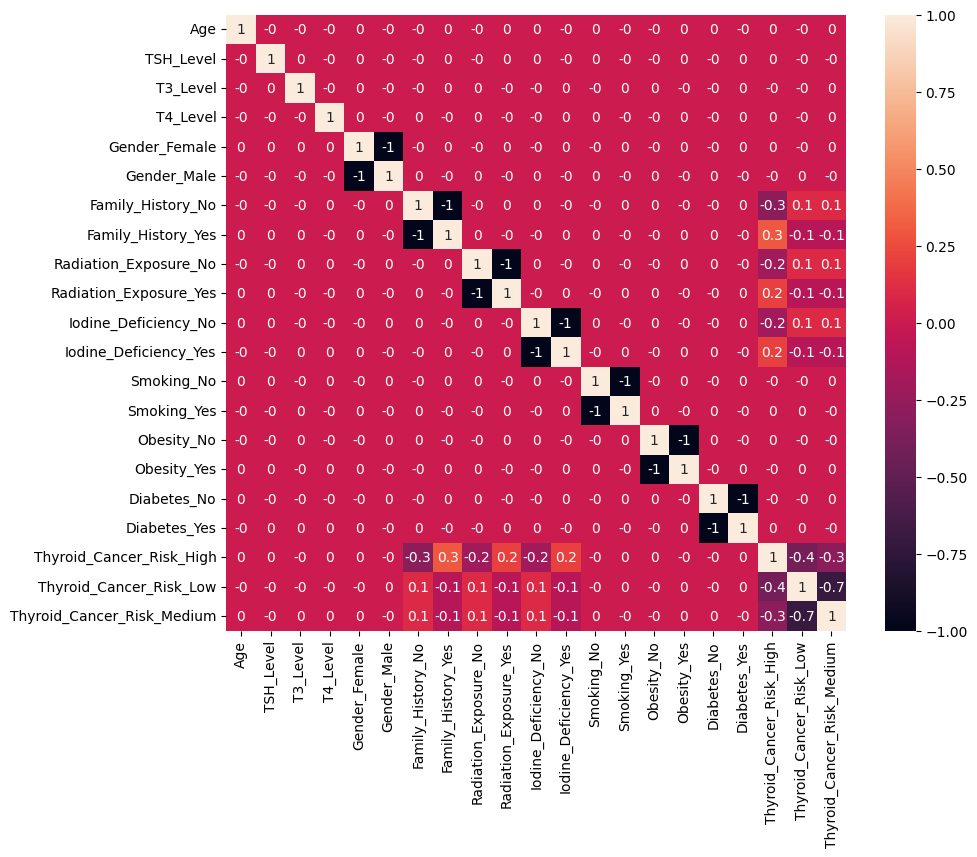

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df_ml.corr().round(1),annot=True)

🤖 MODEL BUILDING & EVALUATION – CELL-WISE REPORT

## 🔀 Train-Test Split

The dataset is divided into training and testing sets using an 80-20 split.

- Training Data → Used to train the model  
- Testing Data → Used to evaluate performance  

This ensures that the model is evaluated on unseen data, improving generalization.

Total dataset size: ~212,000 records

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.25,random_state=100)

In [ ]:
df.shape

(212691, 14)

## 🔀 Train-Test Split

Dataset is split into:

- 75% Training data  
- 25% Testing data  

This ensures unbiased model evaluation.

In [ ]:
X_train

,Age,TSH_Level,T3_Level,T4_Level,Gender_Female,Gender_Male,Family_History_No,Family_History_Yes,Radiation_Exposure_No,Radiation_Exposure_Yes,...,Iodine_Deficiency_Yes,Smoking_No,Smoking_Yes,Obesity_No,Obesity_Yes,Diabetes_No,Diabetes_Yes,Thyroid_Cancer_Risk_High,Thyroid_Cancer_Risk_Low,Thyroid_Cancer_Risk_Medium
Patient_ID,,,,,,,,,,,,,,,,,,,,,
24456,36,1.97,1.43,6.98,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,True
130514,70,2.54,1.32,11.78,True,False,True,False,False,True,...,True,True,False,True,False,True,False,True,False,False
86208,48,3.02,3.30,11.59,False,True,True,False,False,True,...,False,True,False,True,False,True,False,False,False,True
58231,46,1.46,1.43,11.72,True,False,True,False,True,False,...,True,False,True,False,True,True,False,True,False,False
115717,17,7.63,0.96,7.59,True,False,True,False,True,False,...,True,True,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65616,54,8.98,1.35,4.87,False,True,True,False,True,False,...,False,False,True,False,True,False,True,False,False,True
77656,46,7.53,2.07,10.06,True,False,True,False,True,False,...,True,True,False,False,True,True,False,False,False,True
210756,88,0.42,2.74,5.19,True,False,False,True,True,False,...,False,False,True,False,True,True,False,False,True,False


In [ ]:
y_train

,Diagnosis
Patient_ID,
24456,Benign
130514,Benign
86208,Benign
58231,Benign
115717,Benign
...,...
65616,Benign
77656,Benign
210756,Malignant


## 📈 Logistic Regression Model

A baseline classification model used for prediction.

It estimates probability of thyroid cancer occurrence.

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

## 🔮 Model Predictions

The trained model predicts diagnosis on test data.

Output:
- Benign  
- Malignant  

In [ ]:
y_pred = model.predict(X_test)
y_pred

array(['Benign', 'Benign', 'Benign', ..., 'Benign', 'Benign', 'Benign'],
      dtype=object)

## 📊 Model Evaluation

Metrics used:

- Precision  
- Recall  
- F1-score  

These evaluate classification performance.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

      Benign       0.94      0.85      0.89     45160
   Malignant       0.45      0.70      0.55      8013

    accuracy                           0.83     53173
   macro avg       0.70      0.77      0.72     53173
weighted avg       0.87      0.83      0.84     53173



## 🎯 Accuracy

Accuracy measures overall correctness of predictions.

Higher accuracy indicates better model performance.

In [ ]:
accuracy_score(y_pred,y_test)*100

82.6265209786922

## 🔲 Confusion Matrix

Displays:

- True Positives  
- True Negatives  
- False Positives  
- False Negatives  

Important for medical diagnosis evaluation.

In [ ]:
cm = confusion_matrix(y_pred,y_test)
cm

array([[38333,  6827],
       [ 2411,  5602]])

## 🔥 Confusion Matrix Heatmap

Visual representation of confusion matrix.

Insight:
Higher diagonal values indicate better predictions.

<Axes: >

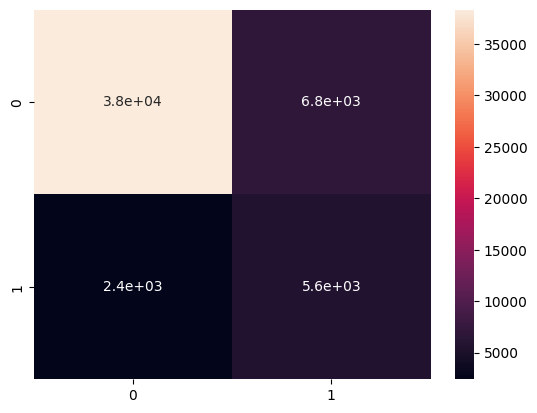

In [ ]:
sns.heatmap(cm,annot=True)

## 🌳 Decision Tree Classifier

Decision Tree captures complex patterns using hierarchical splits.

Better for non-linear relationships.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

## 🔮 Prediction using Decision Tree

The trained Decision Tree model predicts the diagnosis on test data.

It captures complex patterns better than Logistic Regression.

In [ ]:
y_pred = model.predict(X_test)
y_pred

array(['Benign', 'Benign', 'Benign', ..., 'Benign', 'Benign', 'Malignant'],
      dtype=object)

## 📊 Model Evaluation – Decision Tree

Classification metrics are calculated:

- Precision  
- Recall  
- F1-score  

Decision Tree generally performs better in capturing non-linear patterns.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score,confusion_matrix
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

      Benign       0.79      0.81      0.80     39615
   Malignant       0.41      0.37      0.39     13558

    accuracy                           0.70     53173
   macro avg       0.60      0.59      0.60     53173
weighted avg       0.69      0.70      0.70     53173



## 🎯 Accuracy Comparison

The Decision Tree model is compared with Logistic Regression.

Insight:
- Decision Tree may provide higher accuracy  
- Better performance on complex datasets  

In [ ]:
accuracy_score(y_pred,y_test)

0.701032478889662

## 🔲 Confusion Matrix – Decision Tree

The confusion matrix shows classification performance of Decision Tree.

Key focus:
- Reduce false negatives (important in medical diagnosis)  
- Improve detection of malignant cases  

In [ ]:
cm = confusion_matrix(y_pred,y_test)
cm

array([[32231,  7384],
       [ 8513,  5045]])

## 🧠 Key Insights

- Medical datasets are complex and non-linear  
- Feature engineering is crucial  
- Decision Tree outperforms Logistic Regression  
- Minimizing false negatives is critical in healthcare  

## 📌 Conclusion

This project demonstrates the use of machine learning to predict thyroid cancer risk.

Decision Tree models outperform Logistic Regression by capturing complex relationships in medical data, making them more suitable for healthcare applications.

## 🔮 Future Work

- Apply Random Forest and XGBoost  
- Perform hyperparameter tuning  
- Deploy as a web application  
- Include real-time patient data  